# Isoprene Sensitivity Studies

---
Last modified: February 6th, 2025 (JY)

This notebook uses a modified version of vSmartMOM with functions specifically for isoprene to calculate radiances with different amounts of isoprene/water vapor/nitric acid/etc. This notebook is coded in Julia.

In [1]:
# Activate Julia packages
using Pkg;
Pkg.activate("../"); # Activates the vSmartMOM.jl Project.toml file
Pkg.instantiate();

# Using local module, since the current version of vSmartMOM does not support isoprene (not a HITRAN line list species)
include("../src/vSmartMOM.jl");
include("helper_functions.jl");

# Other imports
using Revise, PlotlyBase, Plots, LinearAlgebra, NCDatasets, Format, LaTeXStrings, .vSmartMOM;
using FiniteDiff;

default(fontfamily="Computer Modern");

  Activating project at `~/Documents/Radiative_Transfer/vSmartMOM.jl`


### We now need to specify parameters for the model.

I have downloaded 10 days (2019-07-01 to 2019-07-10) in the MERRA2 folder. You will need to manually download more days if you would like different conditions.

In [3]:
# Parameters for atmospheric profile
date = "20190701";
startTime = "06z";
lat = 2.;
lon = 100.;

merra2_profile = retrieve_merra2_conditions(date, startTime, lat, lon);

pressures = merra2_profile.p_levels ./ 100; # Convert to hPa
pressures_midpoints = merra2_profile.p ./ 100; # Convert to hPa
temperatures = merra2_profile.T;
specific_humidity = merra2_profile.q .* 1000; # Convert from kg/kg (in MERRA2) to g/kg;

ds["T"] = T (576 × 361 × 72 × 4)
  Datatype:    Union{Missing, Float32} (Float32)
  Dimensions:  lon × lat × lev × time
  Attributes:
   long_name            = Air temperature
   units                = K
   _FillValue           = 1.0e15
   missing_value        = 1.0e15
   fmissing_value       = 1.0e15
   scale_factor         = 1.0
   add_offset           = 0.0
   standard_name        = air_temperature
   vmax                 = 1.0e15
   vmin                 = -1.0e15
   valid_range          = Float32[-1.0f15, 1.0f15]



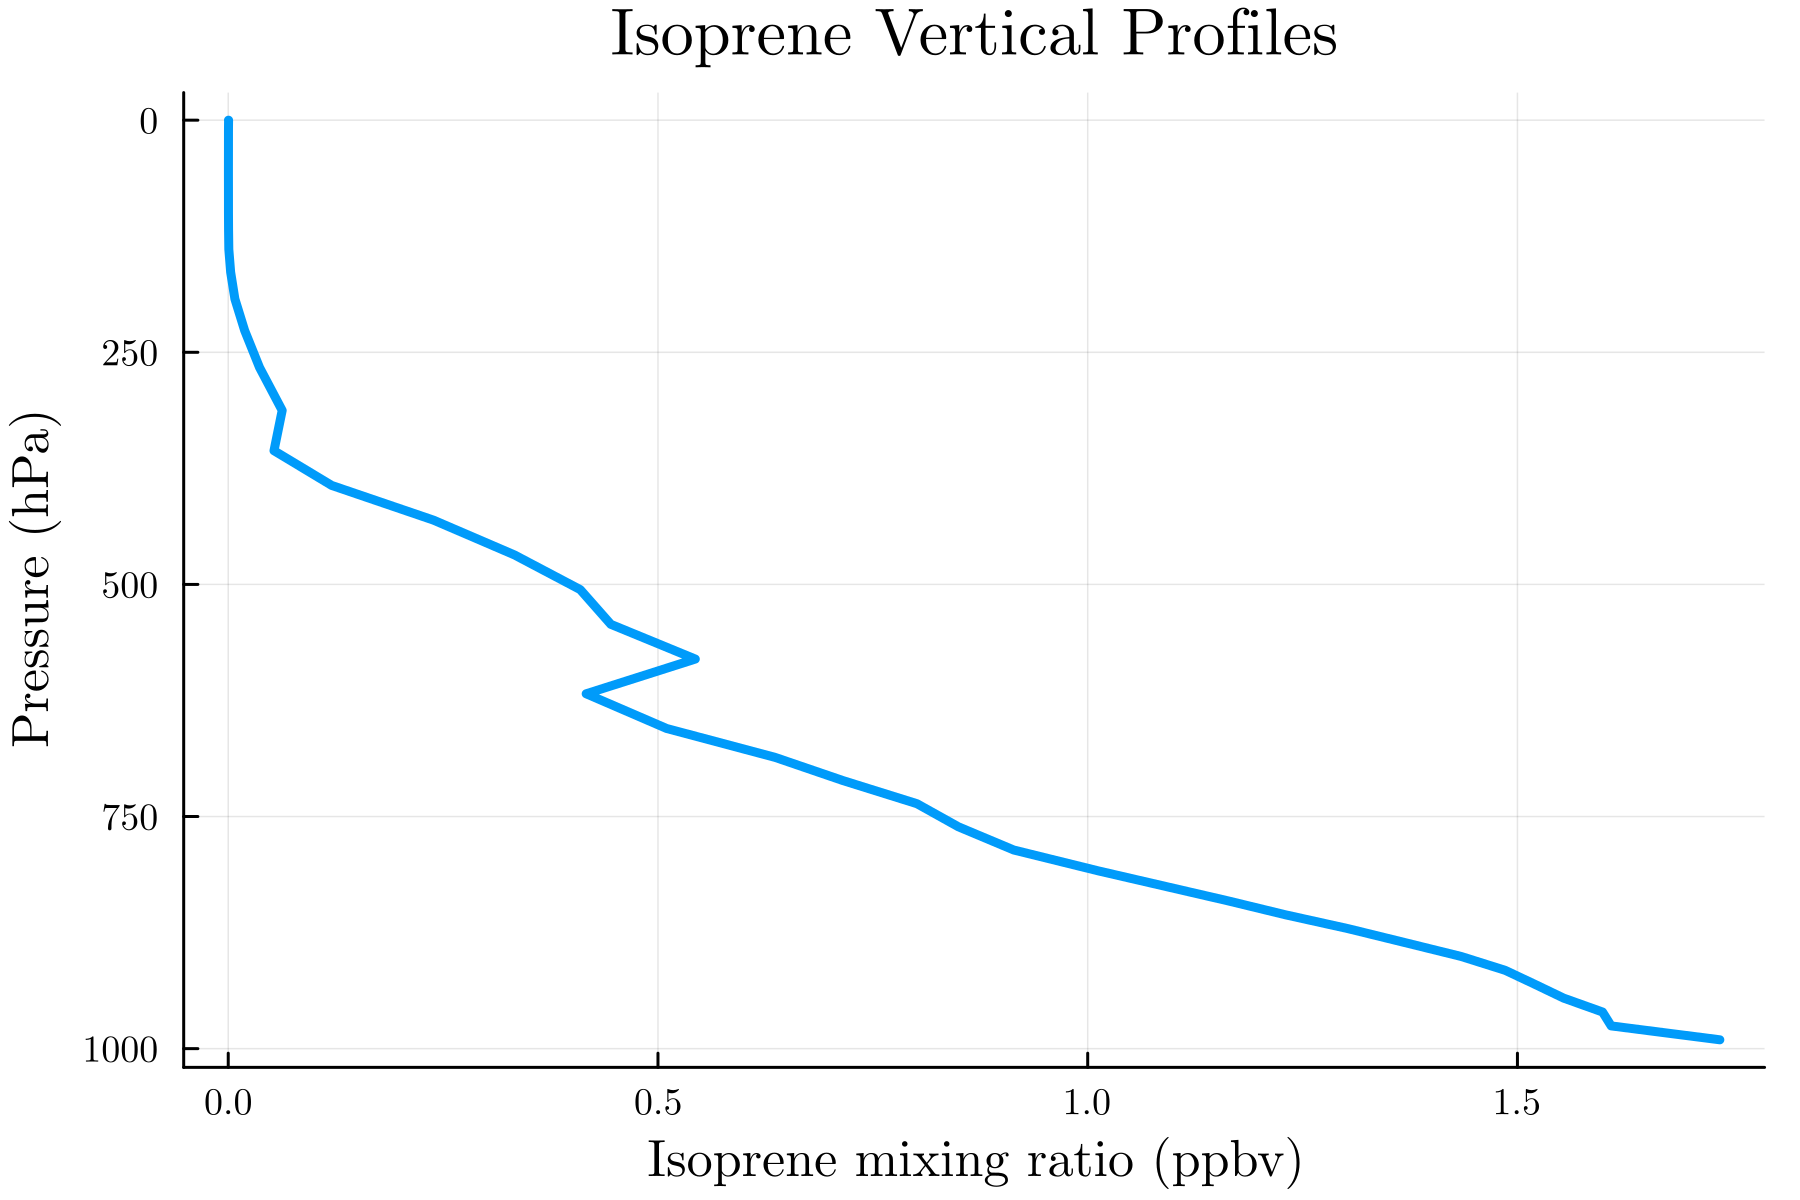

In [ ]:
p = plot(specific_humidity ./ 1000 .* 1e-7 .* 1e9, pressures_midpoints, yflip = true, lw = 3, dpi = 300, label = "")
xlabel!("Isoprene mixing ratio (ppbv)")
ylabel!("Pressure (hPa)")
title!("Isoprene Vertical Profiles")
# savefig(p, "Figures/isoprene_vertical_profile.png")

In [7]:
current_profile = specific_humidity ./ 1000 .* 1e-7; # Get current isoprene vertical profile
total_column = merra2_profile.vcd_dry .* current_profile; # Multiply by vertical column density
total_column = sum(total_column) # Sum for the total column
println("The total column is $(total_column) molec cm-2")

mean_vmr = total_column / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr * 1e9) ppbv")

current_profile_x5 = specific_humidity ./ 1000 .* 1e-7 .* 5; # Get current isoprene vertical profile
total_column_x5 = merra2_profile.vcd_dry .* current_profile_x5; # Multiply by vertical column density
total_column_x5 = sum(total_column_x5) # Sum for the total column
println("The total column is $(total_column_x5) molec cm-2")

mean_vmr_x5 = total_column_x5 / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr_x5 * 1e9) ppbv")

The total column is 1.0351391432445896e16 molec cm-2
The equivalent constant VMR is 0.49235111030987266 ppbv
The total column is 5.175695716222948e16 molec cm-2
The equivalent constant VMR is 2.4617555515493637 ppbv


In [22]:
p = plot(specific_humidity ./ 1000 .* 1e-7 .* 1e9, pressures_midpoints, yflip = true, lw = 3, dpi = 300, label = "1e16 molec cm-2", legend =:topright)
vline!([mean_vmr * 1e9], label = "Equivalent, constant VMR (x1)", color = "cornflowerblue")

plot!(specific_humidity ./ 1000 .* 1e-7 .* 1e9 * 5, pressures_midpoints, yflip = true, lw = 3, dpi = 300, color = "firebrick", label = "5e16 molec cm-2")
vline!([mean_vmr_x5 * 1e9], label = "Equivalent, constant VMR (x5)", color = "firebrick")

xlabel!("[ISOP] (ppbv)")
ylabel!("Pressure (hPa)")
title!("[ISOP] Vertical Profiles")
savefig(p, "figures/isoprene_vertical_profile.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/isoprene_vertical_profile.png"

In [18]:
p = plot(specific_humidity ./ 1000 * 1e-7 * 1e9, pressures_midpoints, yflip = true, lw = 3, dpi = 600, label = L"$[\mathrm{HNO_3}]$ (ppbv)", color = "cornflowerblue")
plot!(specific_humidity ./ 1000 * 1e-7 * 1e9 * 2, pressures_midpoints, yflip = true, lw = 3, dpi = 300, label = L"$[\mathrm{HNO_3}]$ x 2 (ppbv)", color = "cornflowerblue", linestyle=:dash)
vline!([1], label = "1 ppbv", color = "firebrick")

xlabel!(L"$\mathrm{[HNO_3]}$ mixing ratio (ppbv)")
ylabel!("Pressure (hPa)")
title!(L"$\mathrm{HNO_3}$ Vertical Profiles")
savefig(p, "figures/HNO3_profiles.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/HNO3_profiles.png"

## Create instrument kernel!

In [23]:
import InstrumentOperator: FTSInstrument, create_instrument_kernel, FixedKernelInstrument, conv_spectra

ν_min = 890.
ν_max = 910.
Δν = 0.01
ν = ν_min:Δν:ν_max

x = -5:Δν:5
fov = 16.8 #mrads
mopd = 0.8 #cm
FTS = FTSInstrument(0.8, fov * 1e-3, 0.)
unapodized_fts = create_instrument_kernel(FTS, x, 900.0)

p = plot(x, unapodized_fts.parent,label="CrIS Unapodized FTS Lineshape",lw=2, dpi = 300, title = "CrIS Unapodized FTS Instrument Line Shape \n(FOV = 16.8 mrads, MOPD = 0.8 cm)")
ylabel!("Channel Response Function")
xlabel!("σ (cm^-1)")

margin = 0
sampling = 0.625
cris_instrument_kernel = FixedKernelInstrument(unapodized_fts, collect(ν_min+margin:sampling:ν_max-margin))

┌ Info: Center of OffsetArrays is 
│   minimum(abs.(grid_x)) = 0.0
└ @ InstrumentOperator /Users/jamesyoon/.julia/packages/InstrumentOperator/JJWCH/src/prepare_ils.jl:39


(Θ, β) = (0.12700800000000004, 0.0)


FixedKernelInstrument{Float64}([-0.0001938027449118005, -0.00022515990131574464, -0.0002560745521885616, -0.0002864668905839412, -0.0003162580989748737, -0.0003453705508071965, -0.00037372800988458884, -0.00040125582708002165, -0.0004278811338732687, -0.00045353303222005073  …  -0.00011292824838757243, -9.056541516724512e-5, -7.058344327000462e-5, -5.30230478386403e-5, -3.791869420702852e-5, -2.529853680148194e-5, -1.5184374041206004e-5, -7.5916192866803565e-6, -2.5292878448332848e-6, -1.463672932855431e-18], [890.0, 890.625, 891.25, 891.875, 892.5, 893.125, 893.75, 894.375, 895.0, 895.625  …  904.375, 905.0, 905.625, 906.25, 906.875, 907.5, 908.125, 908.75, 909.375, 910.0])

# We can finally run the model!

In [24]:
# No absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/no_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
no_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
no_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, no_absorption[1][1,1,:]);

# Only CO2, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_absorption[1][1,1,:]);

# CO2, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = 0;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_H2O_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_H2O_absorption[1][1,1,:]);

FT_dual = Float64
Finished initializing arrays
Fourier Moment: 0

┌ Info: Processing on: CPU()
│ With FT: Float64
│ Source Function Integration: true
│ Dimensions: (11, 11, 2001)
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/rt_run.jl:108


/2


Looping over layers ... 100%|████████████████████████████| Time: 0:00:04


Fourier Moment: 1/2


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               68.1s /  91.4%           64.3GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    57.2s   91.9%   14.3s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.50s    7.2%  20.8ms   9.66GiB   15.6%  45.8MiB
  interaction                   213    3.19s    5.1%  15.0ms   9.55GiB   15.5%  45.9MiB
    interaction inv2            213    1.05s    1.7%  4.91ms   2.75GiB    4.5%  13.2MiB
    interaction inv1 bla        213    842ms    1.4%  3.95ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [26]:
# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption[1][1,1,:]);

# CO2, ISOP, H2O, O2 absorption but ISOP x 5
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_x5 = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_x5_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_x5[1][1,1,:]);


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
Computing profile for ISOP with vmr [2.8061060675099726e-13, 3.422330792091088e-13, 3.7959910059726096e-13, 4.1038783820113164e-13, 4.166083272139076e-13, 4.2227966332575304e-13, 4.2465917431400157e-13, 4.2646352085284886e-13, 4.2652359297790095e-13, 4.2673227653722277e-13, 4.2585279516060835e-13, 4.2171050154138353e-13, 4.1605308069847525e-13, 4.074657681485405e-13, 3.979811936005717e-13, 3.8654193303955254e-13, 3.769012437260244e-13, 3.6913961594109423e-13, 3.595829184632748e-13, 3.495272267173277e-13, 3.371887260072981e-13, 3.2509281027159884e-13, 3.100484718743246e-13, 2.9689333587157306e-13, 2.85915575659601e-13, 2.778988346108235e-13, 2.7219120966037733e-13, 2.700427785384818e-13, 2.6839841211767634e-13, 2.650610213095206e-13, 2.581584340077825e-13, 2.489701728336513e-13, 2.368115019635297e-13, 2.28945145863

Progress: 100%|█████████████████████████████████████████| Time: 0:00:49


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               70.1s /  91.5%           64.2GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    59.5s   92.7%   14.9s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.39s    6.8%  20.3ms   9.66GiB   15.7%  45.8MiB
  interaction                   213    3.10s    4.8%  14.6ms   9.55GiB   15.5%  45.9MiB
    interaction inv1 bla        213    816ms    1.3%  3.83ms   2.75GiB    4.5%  13.2MiB
    interaction inv2            213    796ms    1.2%  3.74ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [37]:
p1 = plot(cris_instrument_kernel.ν_out, no_absorption_kernel, label="No Absorption", color = "black", lw = 1.5, dpi = 600)
plot!(cris_instrument_kernel.ν_out, CO2_O2_absorption_kernel, label=L"\mathrm{CO_2 + O_2}", lw = 1.5)
plot!(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel, label=L"\mathrm{CO_2 + O_2 + H_2O}", lw = 1.5)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_kernel, label=L"\mathrm{CO_2 + O_2 + H_2O + ISOP}", lw = 1.5)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_kernel, label=L"\mathrm{CO_2 + O_2 + H_2O + ISOP x 5}", lw = 1.5)

title!(L"Convolved ($\mathrm{0.625 cm^{-1}}$) Spectrum")
xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")

p2 = plot(ν, no_absorption[1][1,1,:], label="No Absorption", color = "black", lw = 1.5, dpi = 300)
plot!(ν, CO2_O2_absorption[1][1,1,:], label=L"\mathrm{CO_2 + O_2}", lw = 1.5)
plot!(ν, CO2_O2_H2O_absorption[1][1,1,:], label=L"\mathrm{CO_2 + O_2 + H_2O}", lw = 1.5)
plot!(ν, CO2_O2_ISOP_H2O_absorption[1][1,1,:], label=L"\mathrm{CO_2 + O_2 + H_2O + ISOP}", lw = 1.5)
plot!(ν, CO2_O2_ISOP_H2O_absorption_x5[1][1,1,:], label=L"\mathrm{CO_2 + O_2 + H_2O + ISOP x 5}", lw = 1.5)
title!(L"Simulated ($0.01 \mathrm{cm^{-1}}$) Spectrum")

xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")

p3 = plot(p2, p1, size=(900,500))
savefig(p3, "figures/simulated_v_convolved.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/simulated_v_convolved.png"

In [49]:
nu = 890:0.625:910

p1 = plot(cris_instrument_kernel.ν_out, CO2_O2_absorption_kernel -  no_absorption_kernel, label = L"Contribution from $\mathrm{CO_2 + O_2}$", lw = 1, dpi = 300)
plot!(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel - CO2_O2_absorption_kernel, label = L"Contribution from $\mathrm{H_2O}$", lw = 1)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_kernel - CO2_O2_H2O_absorption_kernel, label = "Contribution from ISOP",)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_kernel - CO2_O2_H2O_absorption_kernel, label = "Contribution from ISOP x 5", lw = 2, color = "black")

xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
title!(L"Retrieval Contributions ($\mathrm{0.625 cm^{-1}}$)")
savefig(p1, "figures/retrieval_contributions.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/retrieval_contributions.png"

## Part I: Isoprene Vertical Profiles

In [50]:
# No ISOP
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = 0;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_H2O_absorption = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_H2O_absorption_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_H2O_absorption[1][1,1,:]);

# VERTICAL PROFILE
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_profile = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_profile_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_profile[1][1,1,:]);

# CONSTANT PROFILE
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = mean_vmr;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_constant = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_constant_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_constant[1][1,1,:]);

# VERTICAL PROFILE x5
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_x5_profile = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_x5_profile_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_x5_profile[1][1,1,:]);

# CONSTANT PROFILE x5
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = mean_vmr_x5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_x5_constant = vSmartMOM.CoreRT.rt_run(model); # Run the model
CO2_O2_ISOP_H2O_absorption_x5_constant_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_x5_constant[1][1,1,:]);

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:06


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
Computing profile for ISOP with vmr 0 for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:48


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               68.9s /  91.6%           64.2GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    58.5s   92.6%   14.6s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.37s    6.9%  20.2ms   9.66GiB   15.7%  45.8MiB
  interaction                   213    3.05s    4.8%  14.3ms   9.55GiB   15.5%  45.9MiB
    interaction inv2            213    874ms    1.4%  4.10ms   2.75GiB    4.5%  13.2MiB
    interaction inv1 bla        213    823ms    1.3%  3.87ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [63]:
p = plot(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel, label = "No ISOP", lw = 1, color = "black",  dpi = 600)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_kernel, label = "ISOP profile, 1e16 molec cm-2", lw = 1.5, color = "cornflowerblue")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_constant_kernel, label = "ISOP constant, 1e16 molec cm-2", lw = 1.5, color = "cornflowerblue", linestyle=:dash)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_profile_kernel, label = "ISOP profile, 5e16 molec cm-2", lw = 1.5, color = "firebrick")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_constant_kernel, label = "ISOP constant, 5e16 molec cm-2", color = "firebrick", lw = 1.5, linestyle=:dash)
ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
title!("Vertical Profile Sensitivity Runs")

p2 = plot(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_profile_kernel - CO2_O2_H2O_absorption_kernel, color = "black", label = "Impact of 1e16 molec cm-2 (profile)", dpi = 300)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_constant_kernel - CO2_O2_ISOP_H2O_absorption_profile_kernel, label = "Impact of just changing profile, 1e16 molec cm-2", color = "cornflowerblue", linewidth = 2)
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_profile_kernel - CO2_O2_H2O_absorption_kernel, color = "black", linestyle=:dash, label = "Impact of 5e16 molec cm-2 (profile)")
plot!(cris_instrument_kernel.ν_out, CO2_O2_ISOP_H2O_absorption_x5_constant_kernel - CO2_O2_ISOP_H2O_absorption_x5_profile_kernel, label = "Impact of just changing profile, 5e16 molec cm-2", color = "firebrick", linewidth = 2)
title!("Contribution of [ISOP] Vertical Profile")

p3 = plot(p, p2, left_margin=5Plots.mm, right_margin=5Plots.mm, size = (900, 500))
xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
savefig(p3, "figures/vertical_profile_sensitivity.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/vertical_profile_sensitivity.png"

# Part II: Water Vapor Effects

In [56]:
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
control = vSmartMOM.CoreRT.rt_run(model); # Run the model
control = conv_spectra(cris_instrument_kernel, ν, control[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity ./ 2;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02 / 2; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
half_water = vSmartMOM.CoreRT.rt_run(model); # Run the model
half_water = conv_spectra(cris_instrument_kernel, ν, half_water[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 2;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02 * 2; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
double_water = vSmartMOM.CoreRT.rt_run(model); # Run the model
double_water = conv_spectra(cris_instrument_kernel, ν, double_water[1][1,1,:]);

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/atmo_prof.jl:79


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
Computing profile for ISOP with vmr [1.4030530337549863e-12, 1.711165396045544e-12, 1.8979955029863046e-12, 2.0519391910056583e-12, 2.083041636069538e-12, 2.1113983166287653e-12, 2.1232958715700076e-12, 2.1323176042642443e-12, 2.1326179648895046e-12, 2.1336613826861138e-12, 2.1292639758030418e-12, 2.108552507706918e-12, 2.080265403492376e-12, 2.0373288407427026e-12, 1.9899059680028582e-12, 1.9327096651977627e-12, 1.884506218630122e-12, 1.8456980797054712e-12, 1.797914592316374e-12, 1.7476361335866386e-12, 1.6859436300364906e-12, 1.6254640513579942e-12, 1.550242359371623e-12, 1.4844666793578653e-12, 1.4295778782980049e-12, 1.3894941730541175e-12, 1.3609560483018867e-12, 1.350213892692409e-12, 1.3419920605883818e-12, 1.325305106547603e-12, 1.2907921700389124e-12, 1.2448508641682565e-12, 1.1840575098176486e-12, 1.144

Progress: 100%|█████████████████████████████████████████| Time: 0:00:49


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               69.9s /  91.9%           64.2GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    59.6s   92.8%   14.9s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.34s    6.8%  20.1ms   9.66GiB   15.7%  45.8MiB
  interaction                   213    3.03s    4.7%  14.2ms   9.55GiB   15.5%  45.9MiB
    interaction inv2            213    835ms    1.3%  3.92ms   2.75GiB    4.5%  13.2MiB
    interaction inv1 bla        213    814ms    1.3%  3.82ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [64]:
p1 = plot(cris_instrument_kernel.ν_out, no_absorption_kernel, label = "No Absorption", lw = 1, dpi = 600, linestyle=:dash, color = "black")# xlimit = [892, 895], ylimit = [0.112, 0.115])
plot!(cris_instrument_kernel.ν_out, CO2_O2_H2O_absorption_kernel, label = L"\mathrm{CO_2 + O_2 + H_2O}", lw = 1, dpi = 300, linestyle=:dash)# xlimit = [892, 895], ylimit = [0.112, 0.115])
plot!(cris_instrument_kernel.ν_out, control, label = "ISOP x5", lw = 2, color = "green", dpi = 600)
plot!(cris_instrument_kernel.ν_out, half_water, label = "ISOP x5, half water vapor", lw = 1, color = "firebrick")
plot!(cris_instrument_kernel.ν_out, double_water, label = "ISOP x5, double water vapor", lw = 1, color = "cornflowerblue")

xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
title!("Water Vapor Sensitivity")

p2 = plot(cris_instrument_kernel.ν_out, control - CO2_O2_H2O_absorption_kernel, label = "ISOP x5 - no ISOP", lw = 3, dpi = 600, color = "black")
plot!(cris_instrument_kernel.ν_out, half_water - control, label = "Half Water - ISOP x5", lw = 1, dpi = 300, color = "firebrick")
plot!(cris_instrument_kernel.ν_out, double_water - control, label = "Double Water - ISOP x5", lw = 1, dpi = 300, color = "cornflowerblue")
title!("Contribution To Retrieval")
ylabel!(L"$\Delta$Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")

p3 = plot(p1, p2, size = (900, 450), left_margin=5Plots.mm, bottom_margin = 5Plots.mm, top_margin = 3Plots.mm)
xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
savefig(p3, "Figures/water_vapor_retrieval.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/Figures/water_vapor_retrieval.png"

# Part III: Nitric Acid Effects

In [66]:
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910-NITRIC-ACID.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;
parameters.absorption_params.vmr["HNO3"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_profile_hno3 = vSmartMOM.CoreRT.rt_run(model); # Run the model
hno3_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_profile_hno3[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910-NITRIC-ACID.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;
parameters.absorption_params.vmr["HNO3"] = specific_humidity ./ 1000 * 1e-7 * 2;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_profile_hno3_x2 = vSmartMOM.CoreRT.rt_run(model); # Run the model
hno3_x2_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_profile_hno3_x2[1][1,1,:]);

parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910-NITRIC-ACID.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;
parameters.absorption_params.vmr["HNO3"] = 1e-9;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
CO2_O2_ISOP_H2O_absorption_profile_hno3_1ppb = vSmartMOM.CoreRT.rt_run(model); # Run the model
hno3_constant_kernel = conv_spectra(cris_instrument_kernel, ν, CO2_O2_ISOP_H2O_absorption_profile_hno3_1ppb[1][1,1,:]);


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
Computing profile for ISOP with vmr [1.4030530337549863e-12, 1.711165396045544e-12, 1.8979955029863046e-12, 2.0519391910056583e-12, 2.083041636069538e-12, 2.1113983166287653e-12, 2.1232958715700076e-12, 2.1323176042642443e-12, 2.1326179648895046e-12, 2.1336613826861138e-12, 2.1292639758030418e-12, 2.108552507706918e-12, 2.080265403492376e-12, 2.0373288407427026e-12, 1.9899059680028582e-12, 1.9327096651977627e-12, 1.884506218630122e-12, 1.8456980797054712e-12, 1.797914592316374e-12, 1.7476361335866386e-12, 1.6859436300364906e-12, 1.6254640513579942e-12, 1.550242359371623e-12, 1.4844666793578653e-12, 1.4295778782980049e-12, 1.3894941730541175e-12, 1.3609560483018867e-12, 1.350213892692409e-12, 1.3419920605883818e-12, 1.325305106547603e-12, 1.2907921700389124e-12, 1.2448508641682565e-12, 1.1840575098176486e-12, 1.144

Progress: 100%|█████████████████████████████████████████| Time: 0:00:48


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:                454s /  97.0%            509GiB /  99.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  5     436s   98.9%   87.1s    493GiB   97.7%  98.6GiB
RT Kernel                       216    4.57s    1.0%  21.2ms   9.66GiB    1.9%  45.8MiB
  interaction                   213    3.20s    0.7%  15.0ms   9.55GiB    1.9%  45.9MiB
    interaction inv2            213    931ms    0.2%  4.37ms   2.75GiB    0.5%  13.2MiB
    interaction inv1 bla        213    839ms    0.2%  3.94ms   2.75GiB    0.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [69]:
p1 = plot(cris_instrument_kernel.ν_out, no_absorption_kernel, label = "No Absorption", lw = 1, dpi = 600, linestyle=:dash, color = "black")
plot!(cris_instrument_kernel.ν_out, control, label = L"\mathrm{CO_2 + O_2 + H_2O + ISOPx5}", lw = 1, dpi = 300, linestyle=:dash)# , xlimit = [892, 895], ylimit = [0.112, 0.115])
plot!(cris_instrument_kernel.ν_out, hno3_kernel, label = L"$\mathrm{HNO_3}$ (profile)", lw = 2, color = "cornflowerblue", dpi = 600)
plot!(cris_instrument_kernel.ν_out, hno3_x2_kernel, label = L"$\mathrm{HNO_3}$ x 2 (profile)", lw = 1, linestyle=:dash, color = "cornflowerblue")
plot!(cris_instrument_kernel.ν_out, hno3_constant_kernel, label = L"$\mathrm{HNO_3}$, 1 ppbv", lw = 1, color = "firebrick")

xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
title!(L"$\mathrm{HNO_3}$ Sensitivity Retrieval")

p2 = plot(cris_instrument_kernel.ν_out, control - CO2_O2_H2O_absorption_kernel, label = "ISOP x5 - no ISOP", lw = 3, dpi = 600, color = "black")
plot!(cris_instrument_kernel.ν_out, hno3_kernel - control, label = L"$\mathrm{HNO_3}$ (profile) - ISOP x5", lw = 1, dpi = 300, color = "cornflowerblue")
plot!(cris_instrument_kernel.ν_out, hno3_x2_kernel - control, label = L"$\mathrm{HNO_3}$ x2 (profile) - ISOP x5", lw = 1, dpi = 300, linestyle=:dash, color = "cornflowerblue")
plot!(cris_instrument_kernel.ν_out, hno3_constant_kernel - control, label = L"$\mathrm{HNO_3}$, 1 ppbv (constant) - ISOP x5", lw = 1, dpi = 300, color = "firebrick")

title!("Contribution To Retrieval")
ylabel!(L"$\Delta$Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")

p3 = plot(p1, p2, size = (900, 450), left_margin=5Plots.mm, right_margin=5Plots.mm, bottom_margin = 5Plots.mm, top_margin = 3Plots.mm)
savefig(p3, "figures/hno3_retrieval.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/hno3_retrieval.png"

# Part IV: Instrument Operator

In [71]:
# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910-INSTRUMENT-OPERATOR.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
precoarsened_output = vSmartMOM.CoreRT.rt_run(model); # Run the model

# CO2, ISOP, H2O, O2 absorption
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/CO2_O2_ISOP_H2O_absorption_890_910.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
instrument_operator_output = vSmartMOM.CoreRT.rt_run(model); # Run the model

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
Computing profile for ISOP with vmr [2.8061060675099726e-13, 3.422330792091088e-13, 3.7959910059726096e-13, 4.1038783820113164e-13, 4.166083272139076e-13, 4.2227966332575304e-13, 4.2465917431400157e-13, 4.2646352085284886e-13, 4.2652359297790095e-13, 4.2673227653722277e-13, 4.2585279516060835e-13, 4.2171050154138353e-13, 4.1605308069847525e-13, 4.074657681485405e-13, 3.979811936005717e-13, 3.8654193303955254e-13, 3.769012437260244e-13, 3.6913961594109423e-13, 3.595829184632748e-13, 3.495272267173277e-13, 3.371887260072981e-13, 3.2509281027159884e-13, 3.100484718743246e-13, 2.9689333587157306e-13, 2.85915575659601e-13, 2.778988346108235e-13, 2.7219120966037733e-13, 2.700427785384818e-13, 2.6839841211767634e-13, 2.650610213095206e-13, 2.581584340077825e-13, 2.489701728336513e-13, 2.368115019635297e-13, 2.28945145863

Progress: 100%|█████████████████████████████████████████| Time: 0:00:08


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:01


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               68.4s /  91.2%           64.2GiB /  96.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    57.7s   92.4%   14.4s   50.3GiB   81.5%  12.6GiB
RT Kernel                       216    4.46s    7.1%  20.6ms   9.66GiB   15.7%  45.8MiB
  interaction                   213    3.17s    5.1%  14.9ms   9.55GiB   15.5%  45.9MiB
    interaction inv2            213    1.00s    1.6%  4.71ms   2.75GiB    4.5%  13.2MiB
    interaction inv1 bla        213    805ms    1.3%  3.78ms   2.75GiB    4.5%  13.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [79]:
T_conv = conv_spectra(cris_instrument_kernel, ν, instrument_operator_output[1][1,1,:]);
p = plot(cris_instrument_kernel.ν_out, T_conv, label="Convolved (Instrument Kernel)", lw = 2, dpi = 300)
plot!(ν_min:0.625:ν_max, precoarsened_output[1][1,1,:], label="Pre-coarsened", lw = 1)

xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
title!("Comparing Coarsened and Convolved Spectra")
savefig(p, "figures/convolved_v_coarsened.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/convolved_v_coarsened.png"